In [104]:
#Jupyter Notebook for Analysis of Experiment 5: Wein's Displacement experiment in Lab III 
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import UnivariateSpline

#plots
plt.rcParams['figure.dpi'] = 120
plt.rcParams.update({'font.size':12, 'font.family':'serif'}) #Setting fonts
plt.rcParams['text.usetex'] = False

import string #For figure labels

# Part I - Finding Wein's Constant

In [105]:
x_raw = np.array([44.13888889,43.80888889,43.47888889,43.14888889,42.81888889,42.48888889,42.15888889,41.82888889,41.49888889,41.16888889,40.83888889,40.50888889,40.17888889,39.84888889,39.51888889,39.18888889,38.85888889,38.52888889,38.19888889,37.86888889,37.53888889,37.20888889,36.87888889,36.54888889,36.21888889,35.88888889,35.55888889,35.22888889,34.89888889,34.56888889,34.23888889,33.90888889,33.57888889,33.24888889,32.91888889,32.58888889,32.25888889,31.92888889,31.59888889,31.26888889,30.93888889,30.60888889,30.27888889,29.94888889,29.61888889,29.28888889,28.95888889,28.62888889,28.29888889,27.96888889,27.63888889,27.30888889,26.97888889,26.64888889,26.31888889,25.98888889,25.65888889,25.32888889,24.99888889,24.66888889,24.33888889,24.00888889])
V_131 = [-3.53,-4.61,-4.96,-5.02,-4.89,-4.97,-5,-4.68,-4.56,-4.54,-4.46,-4.66,-4.58,-4.48,-4.44,-4.38,-4.33,-4.43,-4.32,-4.15,-3.21,-1.72,0.63,2.79,8.04,11.24,13.26,12.24,7.05,5.77,2.35,-1.85,-3.08,-3.33,-3.67,-3.76,-3.75,-3.87,-3.88,-3.83,-3.75,-3.76,-3.67,-3.77,-3.59,-3.52,-3.48,-3.47,-3.39,-3.76,-4.09,-4.17,-3.97,-4.02,-4.15,-4.1,-3.91,-3.74,-3.57,-3.6,-3.61,-3.89]
V_151 = [-6.64,-6.38,-6.4,-6.24,-6.21,-5.99,-5.92,-5.92,-5.87,-5.86,-5.73,-5.62,-5.42,-5.44,-5.44,-5.37,-5.36,-5.49,-5.26,-4.68,-3.73,-2.33,2.31,6.27,12.7,16.8,21.05,21.82,18.04,9.75,5.44,0.95,-1.35,-2.96,-4.11,-4.44,-4.71,-4.81,-4.84,-4.73,-4.63,-4.54,-4.53,-4.44,-4.71,-4.69,-4.69,-4.56,-4.5,-4.35,-4.33,-4.21,-4.13,-3.72,-3.46,-2.91,-2.38,-1.93,-1.55,-1.37,-2.76,-3.46]
V_171 = [-4.68,-3.73,-3.78,-3.83,-3.82,-3.45,-3.56,-3.43,-3.51,-3.42,-3.41,-3.24,-3.34,-3.36,-3.36,-3.42,-3.38,-3.18,-2.81,-2.44,-1.58,0.28,5.6,8.2,15.79,24.88,31.82,31.75,27.64,21.58,13.13,6.59,1.9,0,-1.1,-1.25,-1.88,-1.97,-1.9,-1.94,-1.57,-1.39,-1.32,-1.51,-1.46,-1.37,-1.52,-1.41,-1.46,-1.4,-1.36,-1.24,-1.27,-1.17,-1.46,-1.5,-1.5,-1.46,-1.54,-1.7,-1.82,-1.49]
V_191 = [-0.37,-0.3,-0.31,-0.2,-0.21,-0.02,0.09,0.14,0.18,0.25,0.42,0.38,0.3,0.22,0.34,0.44,0.64,0.78,0.99,1.61,3.22,6.18,10.01,15.13,21.33,33.56,40.83,40.83,35.22,26.02,16.36,11.95,6.61,4.6,3.19,2.24,1.91,1.75,1.66,1.68,1.73,1.7,1.65,1.48,1.41,1.45,1.49,1.5,1.54,1.61,1.69,1.64,1.33,1.54,1.57,1.61,1.68,1.84,1.9,2.07,2.18,1.73]
V_211 = [0.88,1.24,1.42,1.5,1.61,1.66,1.74,1.77,1.77,1.8,1.87,1.9,2.01,2.08,2.19,2.33,2.38,2.15,2.89,4.12,8.21,12.08,23.45,31.79,39.85,54.93,58.59,55.1,44.8,30.77,21.01,13.03,9.49,5.98,5.25,4.4,4.08,4.04,3.98,3.97,3.86,3.79,3.86,3.72,3.64,3.57,3.55,3.66,3.7,3.87,3.92,4,3.92,3.89,3.86,3.71,3.68,3.64,3.49,3.56,3.27,3.59]

In [106]:
#Calculating temps
def findtemp(R_arr):
    Temps = []
    alpha = 4.5*10**(-3)
    R_0 = 37
    T_0 = 25 + 273
    for i in R_arr:
        val = T_0 + ((i/R_0 - 1)/alpha)
        Temps.append(val)
    return Temps
Vs = np.array([131, 151, 171, 191, 211])
Is = np.array([0.32, 0.35, 0.37, 0.39, 0.41])
Rs = Vs/Is
alltemps = findtemp(Rs)
print(alltemps)

[2534.4864864864862, 2666.940368940369, 2851.5264994724453, 3017.180719180719, 3166.6735516003805]


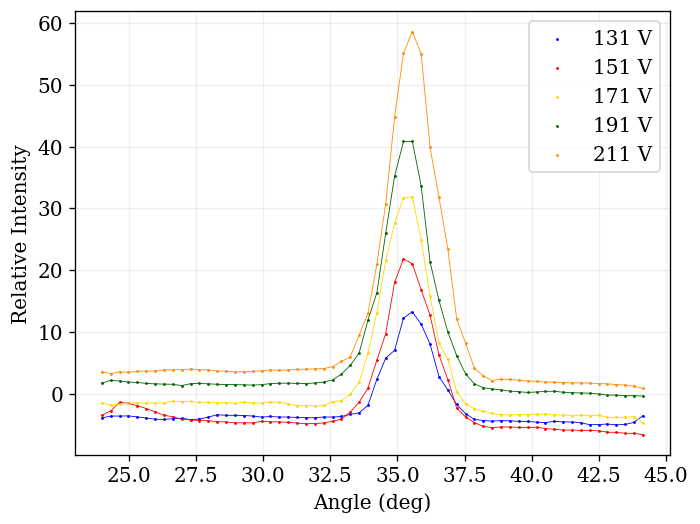

In [107]:
datas = [V_131,V_151,V_171,V_191,V_211]
labels = [131, 151, 171, 191, 211]
col = ['blue', 'red', 'gold', 'darkgreen', 'darkorange']
ydata = []
for i in datas:
    ydata.append(np.array(i))

for i in range(len(ydata)):
    plt.scatter(x_raw, ydata[i], c=col[i], s=0.5, label=f"{labels[i]} V")
    plt.plot(x_raw, ydata[i], c=col[i], lw=0.5)
plt.xlabel("Angle (deg)")
plt.ylabel("Relative Intensity")
plt.legend()
plt.grid(alpha = 0.2)
# plt.xlim(32,38) #Zoom in to peaks
plt.savefig("directangle.jpg")

In [108]:
wavsarray_ = np.array([0.32,0.33,0.34,0.35,0.36,0.37,0.38,0.39,0.4,0.41,0.42,0.43,0.44,0.45,0.46,0.47,0.48,0.49,0.5,0.51,0.52,0.53,0.54,0.55,0.56,0.57,0.58,0.59,0.6,0.61,0.62,0.63,0.64,0.65,0.66,0.67,0.68,0.69,0.7,0.71,0.72,0.73,0.74,0.75,0.76,0.77,0.78,0.79,0.8,0.81,0.82,0.83,0.84,0.85,0.86,0.87,0.88,0.89,0.9,0.91,0.92,0.93,0.94,0.95,0.96,0.97,0.98,0.99,1,1.01,1.02,1.03,1.04,1.05,1.06,1.07,1.08,1.09,1.1,1.11,1.12,1.13,1.14,1.15,1.16,1.17,1.18,1.19,1.2,1.21,1.22,1.23,1.24,1.25,1.26,1.27,1.28,1.29,1.3,1.31,1.32,1.33,1.34,1.35,1.36,1.37,1.38,1.39,1.4,1.41,1.42,1.43,1.44,1.45,1.46,1.47,1.48,1.49,1.5,1.51,1.52,1.53,1.54,1.55,1.56,1.57,1.58,1.59,1.6,1.61,1.62,1.63,1.64,1.65,1.66,1.67,1.68,1.69,1.7,1.71,1.72,1.73,1.74,1.75,1.76,1.77,1.78,1.79,1.8,1.81,1.82,1.83,1.84,1.85,1.86,1.87,1.88,1.89,1.9,1.91,1.92,1.93,1.94,1.95,1.96,1.97,1.98,1.99,2,2.01,2.02,2.03,2.04,2.05,2.06,2.07,2.08,2.09,2.1,2.11,2.12,2.13,2.14,2.15,2.16,2.17,2.18,2.19,2.2,2.21,2.22,2.23,2.24,2.25,2.26,2.27,2.28,2.29,2.3,2.31,2.32,2.33,2.34,2.35,2.36,2.37,2.38,2.39,2.4,2.41,2.42,2.43,2.44,2.45,2.46,2.47,2.48,2.49,2.5])
RIarray = np.array([1.696015997,1.687661228,1.680474916,1.674223707,1.668734299,1.663874858,1.65954303,1.655657945,1.65215474,1.648980697,1.646092474,1.643454064,1.641035287,1.638810634,1.636758386,1.634859926,1.6330992,1.631462285,1.629937046,1.628512857,1.627180369,1.625931328,1.624758415,1.623655123,1.62261564,1.621634767,1.620707832,1.619830632,1.618999372,1.618210619,1.617461258,1.61674846,1.616069645,1.615422463,1.614804761,1.614214569,1.61365008,1.613109631,1.612591693,1.612094855,1.611617815,1.61115937,1.610718404,1.610293883,1.609884849,1.609490411,1.609109737,1.608742057,1.608386648,1.608042839,1.607710001,1.607387546,1.607074923,1.606771617,1.606477144,1.606191048,1.605912905,1.605642311,1.605378889,1.605122283,1.604872158,1.604628198,1.604390102,1.60415759,1.603930394,1.603708263,1.603490956,1.603278248,1.603069924,1.60286578,1.602665625,1.602469273,1.602276552,1.602087296,1.601901347,1.601718555,1.601538777,1.601361879,1.601187729,1.601016205,1.600847189,1.600680568,1.600516234,1.600354086,1.600194025,1.600035957,1.599879792,1.599725445,1.599572833,1.599421878,1.599272503,1.599124637,1.59897821,1.598833155,1.598689409,1.598546909,1.598405598,1.598265418,1.598126316,1.597988237,1.597851133,1.597714955,1.597579655,1.597445189,1.597311515,1.597178589,1.597046371,1.596914824,1.596783909,1.596653591,1.596523834,1.596394604,1.596265871,1.596137601,1.596009765,1.595882333,1.595755277,1.59562857,1.595502185,1.595376096,1.595250278,1.595124708,1.594999361,1.594874216,1.59474925,1.594624443,1.594499773,1.59437522,1.594250766,1.59412639,1.594002076,1.593877805,1.59375356,1.593629324,1.593505081,1.593380815,1.593256511,1.593132153,1.593007727,1.592883219,1.592758615,1.592633901,1.592509065,1.592384093,1.592258973,1.592133693,1.592008241,1.591882606,1.591756776,1.59163074,1.591504488,1.591378008,1.591251291,1.591124327,1.590997105,1.590869617,1.590741853,1.590613803,1.59048546,1.590356813,1.590227854,1.590098576,1.589968969,1.589839026,1.589708738,1.589578099,1.5894471,1.589315734,1.589183993,1.589051871,1.58891936,1.588786454,1.588653145,1.588519427,1.588385293,1.588250737,1.588115753,1.587980335,1.587844475,1.587708168,1.587571409,1.587434191,1.587296508,1.587158356,1.587019727,1.586880617,1.586741021,1.586600932,1.586460346,1.586319258,1.586177661,1.586035552,1.585892925,1.585749775,1.585606097,1.585461887,1.585317139,1.585171849,1.585026013,1.584879624,1.58473268,1.584585175,1.584437105,1.584288466,1.584139252,1.58398946,1.583839085,1.583688124,1.583536571,1.583384423,1.583231675,1.583078323,1.582924364,1.582769792,1.582614604,1.582458797,1.582302365,1.582145305,1.581987613])

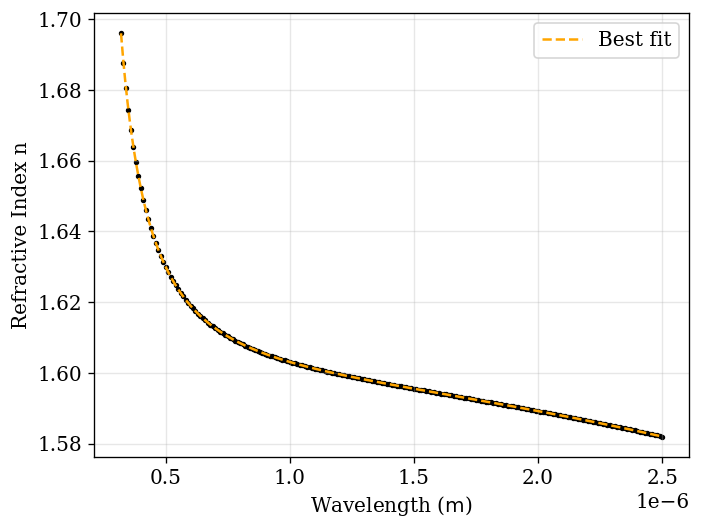

In [109]:
wavsarray = 1e-6 * wavsarray_
plt.scatter(wavsarray, RIarray, c='k',s=5)
plt.xlabel(r"Wavelength ($\mathrm{m}$)")
plt.ylabel("Refractive Index n")
plt.grid(alpha=0.3)

spl = UnivariateSpline(wavsarray,RIarray,s=0)
x_new = np.linspace(min(wavsarray), max(wavsarray), 500)
y_new = spl(x_new) 
plt.plot(x_new, y_new, label='Best fit', color='orange',ls="--")
plt.legend()
plt.savefig("wavsrefind.jpg")

In [110]:
sorted_idx = np.argsort(RIarray)
invwavs = UnivariateSpline(RIarray[sorted_idx], wavsarray[sorted_idx], s=0)

In [111]:
def getns(anglearr):
    minang = np.radians(34.13888889)
    zero = np.radians(82.66)
    prism = np.radians(60)
    n = []
    for i in anglearr:
        subs = abs(i - zero)
        val =  np.sin((prism + subs)/2) / np.sin(prism/2)
        n.append(val)
    n=np.array(n)
    return n

xrad = np.radians(x_raw)
nvals = getns(xrad)
print(nvals)

[1.51537046 1.51912299 1.52286293 1.52659023 1.53030488 1.53400683
 1.53769606 1.54137254 1.54503624 1.54868713 1.55232517 1.55595033
 1.55956259 1.56316192 1.56674829 1.57032166 1.57388201 1.57742931
 1.58096352 1.58448462 1.58799259 1.59148738 1.59496897 1.59843734
 1.60189245 1.60533428 1.60876279 1.61217796 1.61557976 1.61896817
 1.62234314 1.62570466 1.6290527  1.63238723 1.63570823 1.63901565
 1.64230949 1.6455897  1.64885627 1.65210916 1.65534835 1.65857381
 1.66178552 1.66498345 1.66816756 1.67133785 1.67449427 1.67763681
 1.68076543 1.68388012 1.68698084 1.69006756 1.69314028 1.69619895
 1.69924355 1.70227407 1.70529046 1.70829271 1.7112808  1.71425469
 1.71721437 1.72015981]


In [112]:
pred_wavs = invwavs(nvals)
print(pred_wavs*1e9)

[5594.52921056 5356.48333155 5140.5868966  4944.02866114 4764.05016325
 4597.94540797 4443.06071001 4296.7944005  4156.59664887 4019.96916566
 3884.46500477 3747.68829142 3607.29397647 3460.98758322 3306.52494755
 3141.71195628 2964.40428027 2772.50710666 2563.97486533 2336.7949576
 2089.0966141  1821.35371961 1542.42669701 1277.74650318 1060.48267406
  901.71992072  789.42686274  708.29842957  647.5257941   600.38589595
  562.72101496  531.88460787  506.12962226  484.26146326  465.43680227
  449.04347433  434.625926    421.8382003   410.41219687  400.13694523
  390.84393215  382.396768    374.68383397  367.61290285  361.10672559
  355.10012227  349.53852078  344.37416765  339.56671946  335.08020833
  330.88621127  326.95822682  323.2703806   319.79742035  316.51471093
  313.3982292   310.42455899  307.57088596  304.81499242  302.13525222
  299.51062547  296.92065335]


[7.894268627394485e-07, 7.082984295697993e-07, 7.894268627394485e-07, 7.894268627394485e-07, 7.894268627394485e-07]
[0.0020007917156825545, 0.0018889896750767642, 0.002251071618496934, 0.0023818435094607876, 0.002499857167159875]


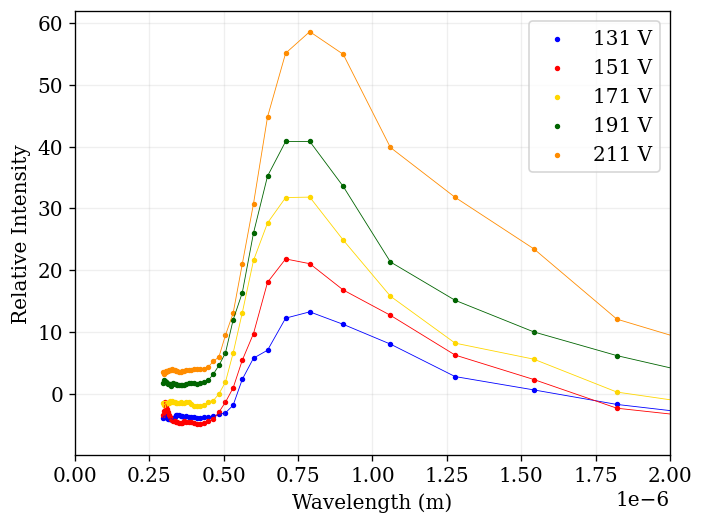

In [113]:
for i in range(len(ydata)):
    plt.scatter(pred_wavs, ydata[i], c=col[i], s=5, label=f"{labels[i]} V")
    plt.plot(pred_wavs, ydata[i], c=col[i], lw=0.5)
plt.xlabel("Wavelength (m)")
plt.ylabel("Relative Intensity")
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
plt.legend()
plt.grid(alpha = 0.2)
plt.xlim(0,2e-6)


maxwavs = []
for i in ydata:
    peak_index = np.argmax(i)
    maxwavs.append(pred_wavs[peak_index])

print(maxwavs)
Temps = np.array([2533.49, 2665.94, 2850.53, 3016.18, 3165.67])

weins = []
for i in range(len(alltemps)):
    cval = maxwavs[i]*alltemps[i]
    weins.append(cval)
print(weins)


[-7.531269644865789e-07, -7.270963274446907e-07, -7.465164538310916e-07, -7.465164538310916e-07, -7.927900284195016e-07]
[-0.001908790114099822, -0.0019391225477705307, -0.002128711450391556, -0.002252375051050333, -0.00251050721496855]


Text(0.5, 1.0, 'Smoothened curves')

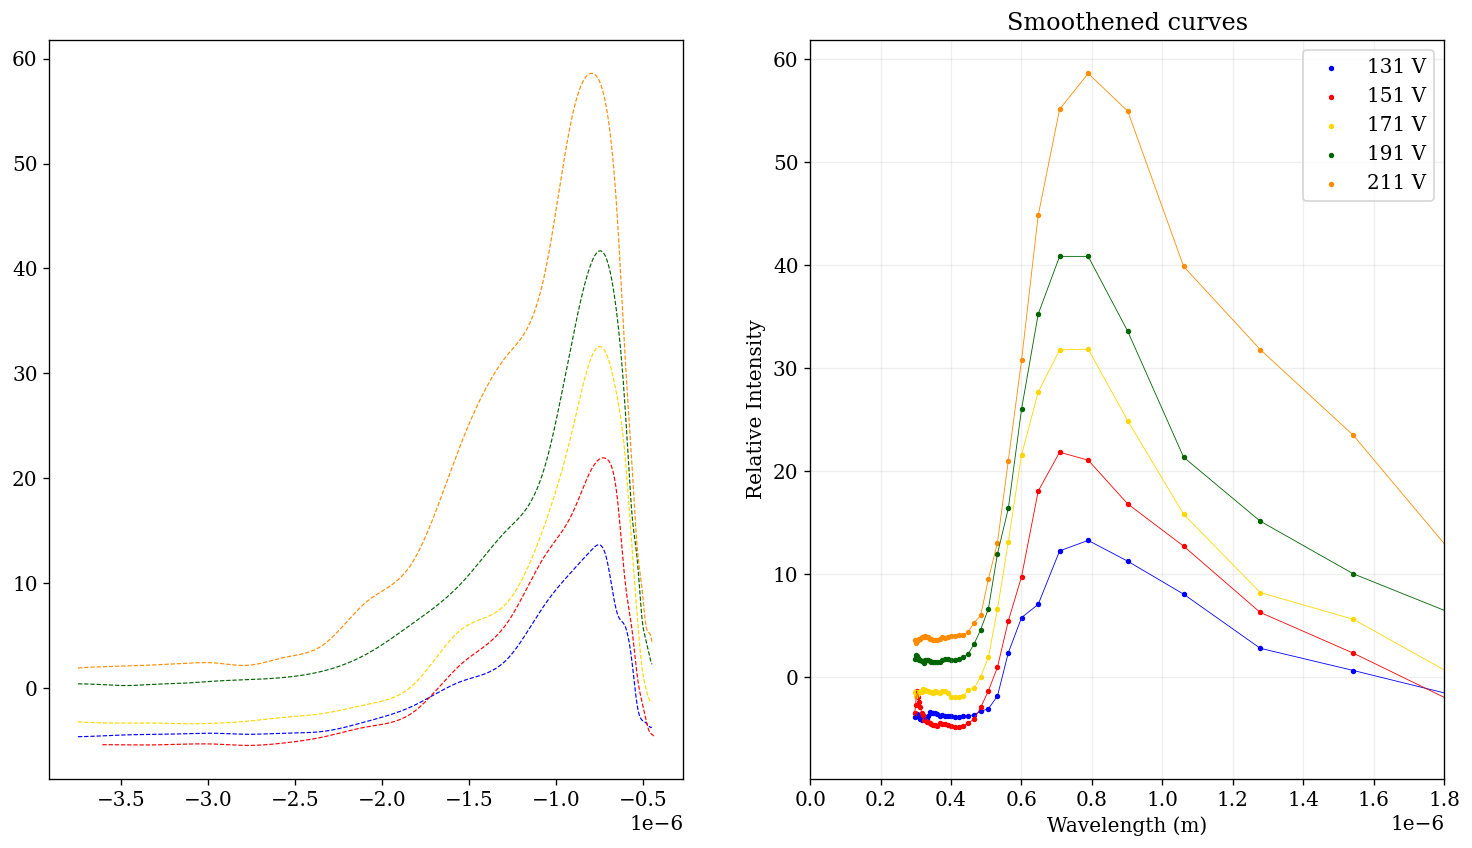

In [114]:
fig,axes = plt.subplots(nrows=1, ncols=2, figsize=(15,8))
newpeaks = []
for i in ydata:
    cp = np.argmax(i)
    colind = np.where(ydata == i)[0][0]
    indrange = i[cp-15:cp+10]
    tests = -pred_wavs
    wavrange = tests[cp-15:cp+10]
    splrange = UnivariateSpline(wavrange,indrange,s=0)
    x_range = np.linspace(min(wavrange), max(wavrange), 500)
    y_range = splrange(x_range) 
    axes[0].plot(x_range, y_range, label='Best fit', color=col[colind],ls="--",lw=0.7)
    peak2 = np.argmax(y_range)
    peakwav2 = x_range[peak2]
    newpeaks.append(peakwav2)
print(newpeaks)

for i in range(len(ydata)):
    plt.scatter(pred_wavs, ydata[i], c=col[i], s=5, label=f"{labels[i]} V")
    axes[1].plot(pred_wavs, ydata[i], c=col[i], lw=0.5)
plt.xlabel("Wavelength (m)")
plt.ylabel("Relative Intensity")
plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
plt.legend()
plt.grid(alpha = 0.2)
plt.xlim(0,1.8e-6)


weins2 = []
for i in range(len(alltemps)):
    cval2 = newpeaks[i]*alltemps[i]
    weins2.append(cval2)
print(weins2)

plt.title("Smoothened curves")


# # ...existing code...
# fig,axes = plt.subplots(nrows=1, ncols=2, figsize=(15,8))
# newpeaks = []
# sm_x_list = []
# sm_y_list = []

# for idx, i in enumerate(ydata):
#     cp = np.argmax(i)
#     # safe slicing bounds
#     start = max(0, cp - 15)
#     end = min(len(i), cp + 10)
#     indrange = i[start:end]
#     wavrange = wavsarray[start:end]

#     # require at least 4 points for a stable spline
#     if len(wavrange) < 4:
#         # fallback: use whole range if slice too small
#         wavrange = wavsarray
#         indrange = i

#     splrange = UnivariateSpline(wavrange, indrange, s=0)
#     x_range = np.linspace(wavrange[0], wavrange[-1], 500)
#     y_range = splrange(x_range)

#     # left panel: plot the smooth fit for the sliced region
#     axes[0].plot(x_range, y_range, label=f'{labels[idx]} V fit', color=col[idx], ls="--", lw=0.7)

#     peak2 = np.argmax(y_range)
#     peakwav2 = x_range[peak2]
#     newpeaks.append(peakwav2)

#     sm_x_list.append(x_range)
#     sm_y_list.append(y_range)

# print(newpeaks)

# # right panel: scatter raw data (using predicted wavelengths) and overplot the smoothened sliced fits
# for idx in range(len(ydata)):
#     axes[1].scatter(pred_wavs, ydata[idx], c=col[idx], s=5, label=f"{labels[idx]} V")
#     axes[1].plot(sm_x_list[idx], sm_y_list[idx], c=col[idx], lw=0.9)

# axes[1].set_xlabel("Wavelength (m)")
# axes[1].set_ylabel("Relative Intensity")
# axes[1].ticklabel_format(axis='x', style='sci', scilimits=(0,0))
# axes[1].legend()
# axes[1].grid(alpha = 0.2)
# axes[1].set_xlim(0,1.8e-6)

# weins2 = []
# for i in range(len(alltemps)):
#     cval2 = newpeaks[i]*alltemps[i]
#     weins2.append(cval2)
# print(weins2)

# plt.suptitle("Smoothened curves")
# # ...existing




In [115]:
# fig, ax = plt.subplots(figsize=(7, 7))

# newpeaks = []

# for i, y_arr in enumerate(ydata):
#     cp = np.argmax(y_arr)
#     start, end = max(0, cp-15), min(len(y_arr), cp+15)
    
#     tests = -pred_wavs 
#     wavrange = tests[start:end]
#     indrange = y_arr[start:end]
    
#     splrange = UnivariateSpline(wavrange, indrange, s=0)
#     x_range = np.linspace(min(wavrange), max(wavrange), 500)
#     y_range = splrange(x_range) 
    
#     peak_idx = np.argmax(y_range)
#     peak_wav = x_range[peak_idx]
#     newpeaks.append(peak_wav)
    
#     ax.plot(x_range, y_range, 
#             label=f'Best fit: {labels[i]} V', 
#             color=col[i], 
#             linestyle="--", 
#             linewidth=1.5)
    
#     ax.scatter(peak_wav, np.max(y_range), color=col[i], s=30, zorder=5)

# # ax.set_title("Smoothened Intensity Curves", fontsize=14, fontweight='bold', pad=15)
# ax.set_xlabel(r"Wavelength $\lambda$ (m)", fontsize=12)
# ax.set_ylabel(r"Relative Intensity $I_{rel}$", fontsize=12)

# ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
# ax.grid(True, linestyle=':', alpha=0.6)

# # Legend moved to the left and size increased slightly
# ax.legend(loc='upper left', fontsize='medium', frameon=True, shadow=True, framealpha=0.9)

# all_wav_min = min([newpeaks[i] - (newpeaks[i]*0.1) for i in range(len(newpeaks))])
# all_wav_max = max([newpeaks[i] + (newpeaks[i]*0.1) for i in range(len(newpeaks))])

# # Adjusted padding to ensure the curves are centered and clear
# ax.set_xlim(all_wav_min-1.2e-6, all_wav_max+0.6e-6)

# plt.tight_layout()
# # plt.show()

# print("Refined Peaks (m):", newpeaks)
# plt.savefig("smoothenedweins.jpg")

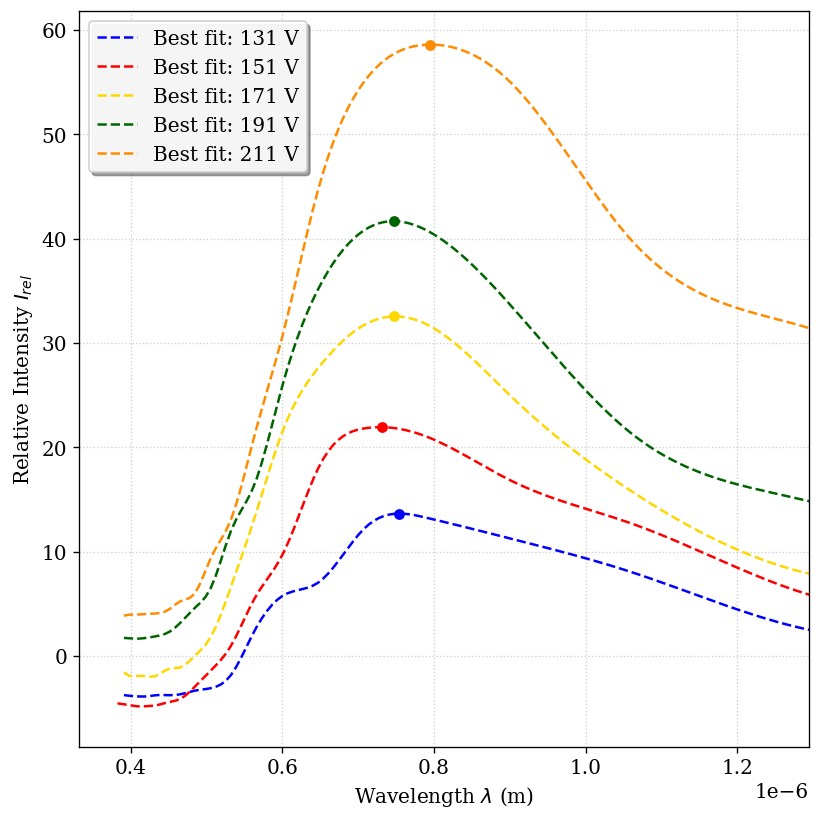

Refined Peaks (m): [7.541096543982626e-07, 7.313836402589448e-07, 7.473825113937143e-07, 7.473825113937143e-07, 7.944725124255523e-07]


In [116]:
fig, ax = plt.subplots(figsize=(7, 7))

newpeaks = []

for i, y_arr in enumerate(ydata):
    cp = np.argmax(y_arr)
    start, end = max(0, cp-15), min(len(y_arr), cp+15)
    
    # Grab raw data
    wav_raw = pred_wavs[start:end]
    ind_raw = y_arr[start:end]
    
    # FIX: Sort by wavelength so UnivariateSpline doesn't crash
    sort_idx = np.argsort(wav_raw)
    wavrange = wav_raw[sort_idx]
    indrange = ind_raw[sort_idx]
    
    splrange = UnivariateSpline(wavrange, indrange, s=0)
    x_range = np.linspace(min(wavrange), max(wavrange), 500)
    y_range = splrange(x_range) 
    
    peak_idx = np.argmax(y_range)
    peak_wav = x_range[peak_idx]
    newpeaks.append(peak_wav)
    
    ax.plot(x_range, y_range, 
            label=f'Best fit: {labels[i]} V', 
            color=col[i], 
            linestyle="--", 
            linewidth=1.5)
    
    ax.scatter(peak_wav, np.max(y_range), color=col[i], s=30, zorder=5)

ax.set_xlabel(r"Wavelength $\lambda$ (m)", fontsize=12)
ax.set_ylabel(r"Relative Intensity $I_{rel}$", fontsize=12)
ax.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper left', fontsize='medium', frameon=True, shadow=True, framealpha=0.9)

all_wav_min = min(newpeaks)
all_wav_max = max(newpeaks)
ax.set_xlim(all_wav_min-0.4e-6, all_wav_max+0.5e-6)

plt.tight_layout()
plt.savefig("smoothenedweins.jpg")
plt.show()

print("Refined Peaks (m):", newpeaks)

-0.0041207956860219025


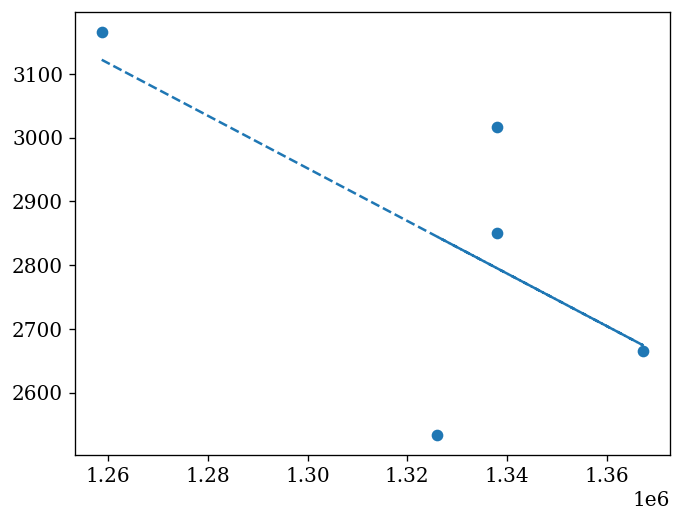

In [117]:
plt.scatter(1/np.array(newpeaks), Temps)
m,c = np.polyfit(1/np.array(newpeaks), Temps, deg=1)
yfit = m*(1/np.array(newpeaks)) + c
plt.plot((1/np.array(newpeaks)),yfit,ls='--')
print(m)

# Part II - Finding Planck's Constant

In [118]:
Pvolts = [130,150,170,190,210]
PAmps = [0.32,0.34,0.37,0.39,0.41]
PInts = [11.39,15.22,18.2,21.47,24.81]

In [119]:
#Finding 5C2 combinations for ratio
ratio_combinations = []
for i in PInts:
    for j in PInts:
        if i != j and (j/i) not in ratio_combinations:
            ratio_combinations.append(i/j)
print(ratio_combinations)

[0.7483574244415243, 0.6258241758241759, 0.5305076851420587, 0.4590890769850867, 0.8362637362637363, 0.7088961341406614, 0.6134623135832327, 0.847694457382394, 0.7335751713018944, 0.8653768641676743]
